In [8]:
import pandas as pd
import os

fights = pd.read_csv("../data/ufc_gold_dataset_final.csv")
fighters = pd.read_csv("../data/ufc_fighters_final.csv")

#check dataset
# print(fights.head())
# print(fighters.head())
# print(fights.shape)
# print(fighters.shape)
# print(fighters.isnull().sum())
# print(fights.isnull().sum())
#

In [9]:
# building feature set

# merge fighter 1 stats
df = fights.merge(fighters, left_on="Fighter_1", right_on="Fighter_Name", how="left")
df = df.rename(columns={col: "F1_" + col for col in fighters.columns if col != "Fighter_Name"})

# merge fighter 2 stats
df = df.merge(fighters, left_on="Fighter_2", right_on="Fighter_Name", how="left")
df = df.rename(columns={col: "F2_" + col for col in fighters.columns if col != "Fighter_Name"})

# print(df.shape)
# print(df.head())

# 1 means Fighter_1 won, 0 means Fighter_2 won
df["target"] = (df["Winner"] == df["Fighter_1"]).astype(int)

# check the balance
#print(df["target"].value_counts())

#note stats bias fighter 1 as winner

pct_cols = ["F1_Str_Acc", "F1_Str_Def", "F1_TD_Acc", "F1_TD_Def",
            "F2_Str_Acc", "F2_Str_Def", "F2_TD_Acc", "F2_TD_Def"]

for col in pct_cols:
    df[col] = df[col].str.replace("%", "").astype(float) / 100

#print(df[pct_cols].head())

df["F1_Reach"] = df["F1_Reach"].str.replace('"', '').astype(float)
df["F2_Reach"] = df["F2_Reach"].str.replace('"', '').astype(float)


df["reach_diff"] = df["F1_Reach"] - df["F2_Reach"]
df["slpm_diff"] = df["F1_SLpM"] - df["F2_SLpM"]
df["str_acc_diff"] = df["F1_Str_Acc"] - df["F2_Str_Acc"]
df["sapm_diff"] = df["F1_SApM"] - df["F2_SApM"]
df["str_def_diff"] = df["F1_Str_Def"] - df["F2_Str_Def"]
df["td_avg_diff"] = df["F1_TD_Avg"] - df["F2_TD_Avg"]
df["td_acc_diff"] = df["F1_TD_Acc"] - df["F2_TD_Acc"]
df["td_def_diff"] = df["F1_TD_Def"] - df["F2_TD_Def"]
df["sub_avg_diff"] = df["F1_Sub_Avg"] - df["F2_Sub_Avg"]
df["win_diff"] = df["F1_Wins"] - df["F2_Wins"]
df["loss_diff"] = df["F1_Losses"] - df["F2_Losses"]

feature_cols = ["reach_diff", "slpm_diff", "str_acc_diff", "sapm_diff",
                "str_def_diff", "td_avg_diff", "td_acc_diff", "td_def_diff",
                "sub_avg_diff", "win_diff", "loss_diff"]

print(df[feature_cols].describe())

        reach_diff    slpm_diff  str_acc_diff    sapm_diff  str_def_diff  \
count  7543.000000  8597.000000   8597.000000  8597.000000   8597.000000   
mean      0.103540     0.140646      0.010725    -0.156992      0.019361   
std       3.286386     1.602971      0.118247     1.641952      0.111451   
min     -12.000000   -12.520000     -0.700000   -20.230000     -0.620000   
25%      -2.000000    -0.880000     -0.060000    -1.060000     -0.040000   
50%       0.000000     0.130000      0.010000    -0.120000      0.010000   
75%       2.000000     1.160000      0.070000     0.820000      0.080000   
max      14.000000    19.390000      0.830000    13.650000      0.720000   

       td_avg_diff  td_acc_diff  td_def_diff  sub_avg_diff     win_diff  \
count  8597.000000  8597.000000  8597.000000   8597.000000  8597.000000   
mean      0.121139     0.026103     0.037362      0.036129     1.933349   
std       1.766516     0.270765     0.286946      1.017002    11.293768   
min     -11.770

In [10]:
#training
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X = df[feature_cols].fillna(df[feature_cols].median())
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

preds = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, preds))

Accuracy: 0.6947674418604651


In [11]:
# which stats are most important
import pandas as pd
importances = pd.Series(model.feature_importances_, index=feature_cols)
print(importances.sort_values(ascending=False))

slpm_diff       0.119225
win_diff        0.107280
sapm_diff       0.105726
td_def_diff     0.097189
td_avg_diff     0.095274
str_acc_diff    0.089385
loss_diff       0.087723
td_acc_diff     0.085462
str_def_diff    0.080570
sub_avg_diff    0.071748
reach_diff      0.060418
dtype: float64


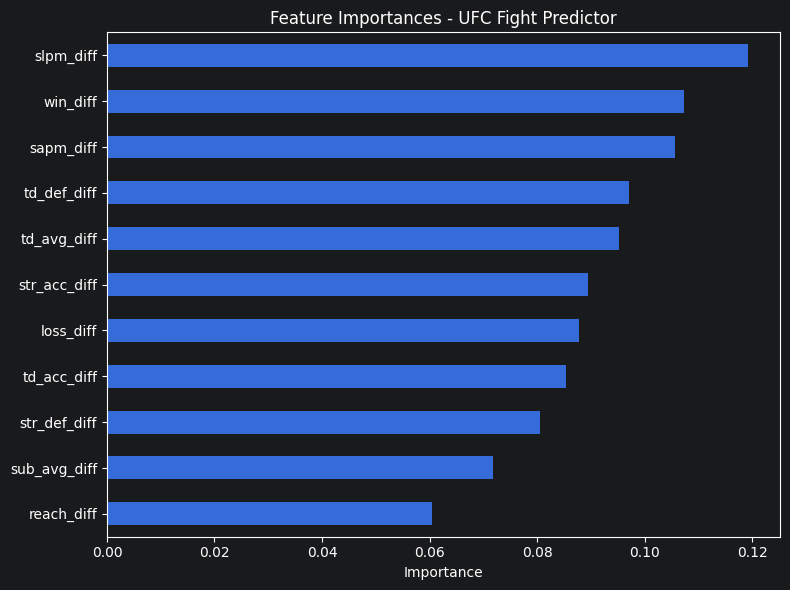

In [12]:
#visualize
import matplotlib.pyplot as plt

importances.sort_values().plot(kind="barh", figsize=(8, 6))
plt.title("Feature Importances - UFC Fight Predictor")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("../feature_importances.png")
plt.show()

In [13]:
#save model
import joblib

joblib.dump(model, "../models/random_forest.pkl")
print("Model saved.")

Model saved.
